# 5.16, 5.17

In [1]:
#First, to load /home/aadithya-iyer/Github/IIScSecondSem/IISC_PRNN/Assignment 1/PRNN_2026_A1_data/dataset_1.csv
import pandas as pd
import numpy as np
# Load the dataset
file_path = '/home/aadithya-iyer/Github/IIScSecondSem/IISC_PRNN/Assignment 1/Data_Codes_Renamed/dataset_1.csv'
data = pd.read_csv(file_path)
# Display the first few rows of the dataset
print(data.head())
#Print the shape of the dataset
print(f"Dataset shape: {data.shape}")

   feature_1     target
0  -2.509198  -8.934091
1   9.014286  36.774545
2   4.639879  21.369160
3   1.973170  12.157523
4  -6.879627 -25.587989
Dataset shape: (5000, 2)


In [2]:
# Bias-Variance Analysis with Scaling
import numpy as np
import matplotlib.pyplot as plt

# Split Dataset 1
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

split = int(0.8 * len(X))
X_train_raw = X[:split]
y_train = y[:split]
X_test_raw = X[split:]
y_test = y[split:]

# --- Feature Scaling (Crucial for numerical stability in Polynomial Regression) ---
mean_X = np.mean(X_train_raw)
std_X = np.std(X_train_raw)

X_train = (X_train_raw - mean_X) / std_X
X_test = (X_test_raw - mean_X) / std_X

class LinearRegression:
    def fit(self, X, y):
        # Add intercept term
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        # Closed-form solution
        self.theta_ = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    
    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b.dot(self.theta_)

class PolynomialRegression:
    def __init__(self, degree):
        self.degree = degree
    
    def fit(self, X, y):
        X_poly = self._polynomial_features(X)
        X_poly_b = np.c_[np.ones((X_poly.shape[0], 1)), X_poly]
        self.theta_ = np.linalg.pinv(X_poly_b.T.dot(X_poly_b)).dot(X_poly_b.T).dot(y)
    
    def predict(self, X):
        X_poly = self._polynomial_features(X)
        X_poly_b = np.c_[np.ones((X_poly.shape[0], 1)), X_poly]
        return X_poly_b.dot(self.theta_)
    
    def _polynomial_features(self, X):
        features = [X**i for i in range(1, self.degree + 1)]
        return np.hstack(features)

# Bootstrap estimation
B = 100
preds_d1 = []
preds_d15 = []

for b in range(B):
    idx = np.random.choice(len(X_train), len(X_train), replace=True)
    X_boot = X_train[idx]
    y_boot = y_train[idx]

    # d = 1
    lin = LinearRegression()
    lin.fit(X_boot, y_boot)
    preds_d1.append(lin.predict(X_test))

    # d = 15
    poly = PolynomialRegression(15)
    poly.fit(X_boot, y_boot)
    preds_d15.append(poly.predict(X_test))

preds_d1 = np.array(preds_d1)
preds_d15 = np.array(preds_d15)

mean_pred_d1 = np.mean(preds_d1, axis=0)
mean_pred_d15 = np.mean(preds_d15, axis=0)

bias2_d1 = np.mean((mean_pred_d1 - y_test)**2)
bias2_d15 = np.mean((mean_pred_d15 - y_test)**2)

var_d1 = np.mean(np.var(preds_d1, axis=0))
var_d15 = np.mean(np.var(preds_d15, axis=0))

print("Linear Regression (d=1)")
print(f"Bias^2: {bias2_d1:.6f}")
print(f"Variance: {var_d1:.6f}")

print("\nPolynomial Regression (d=15)")
print(f"Bias^2: {bias2_d15:.6f}")
print(f"Variance: {var_d15:.6f}")


Linear Regression (d=1)
Bias^2: 2.358044
Variance: 0.001228

Polynomial Regression (d=15)
Bias^2: 2.352938
Variance: 0.010745


Frequentist Variance of slope parameter: 0.000543
Bayesian Posterior Variance of slope parameter: 0.129381


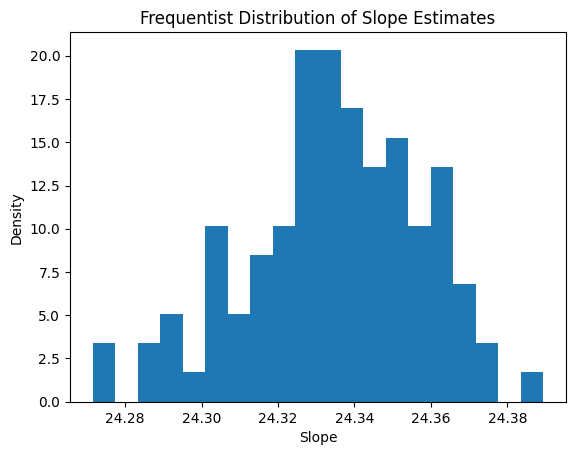

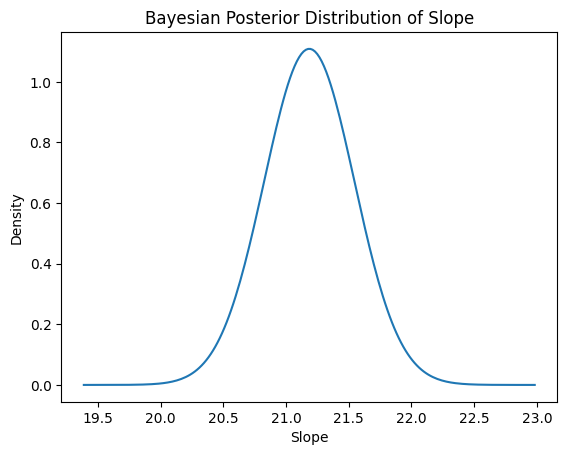

In [3]:
# Collect slope estimates from bootstrap models
slopes = []

for b in range(B):

    idx = np.random.choice(len(X_train), len(X_train), replace=True)

    X_boot = X_train[idx]
    y_boot = y_train[idx]

    lin = LinearRegression()
    lin.fit(X_boot, y_boot)

    slopes.append(lin.theta_[1])   # slope parameter

slopes = np.array(slopes)

frequentist_variance = np.var(slopes)

print(f"Frequentist Variance of slope parameter: {frequentist_variance:.6f}")

X_design = np.c_[np.ones((X_train.shape[0], 1)), X_train]

sigma2 = np.var(y_train)   # noise variance estimate
tau2 = 1.0                 # prior variance

posterior_cov = np.linalg.inv(
    (X_design.T @ X_design) / sigma2 + np.eye(2) / tau2
)

bayesian_variance = posterior_cov[1,1]

print(f"Bayesian Posterior Variance of slope parameter: {bayesian_variance:.6f}")

import matplotlib.pyplot as plt

plt.hist(slopes, bins=20, density=True)
plt.title("Frequentist Distribution of Slope Estimates")
plt.xlabel("Slope")
plt.ylabel("Density")
plt.show()

import scipy.stats as stats

# Posterior mean (MAP estimate)
theta_map = np.linalg.inv(
    (X_design.T @ X_design) / sigma2 + np.eye(2) / tau2
) @ ((X_design.T @ y_train) / sigma2)

posterior_mean = theta_map[1]

# Generate range for plotting posterior distribution
x_vals = np.linspace(posterior_mean - 5*np.sqrt(bayesian_variance),
                     posterior_mean + 5*np.sqrt(bayesian_variance), 200)

posterior_pdf = stats.norm.pdf(x_vals, posterior_mean, np.sqrt(bayesian_variance))

plt.figure()
plt.plot(x_vals, posterior_pdf)
plt.title("Bayesian Posterior Distribution of Slope")
plt.xlabel("Slope")
plt.ylabel("Density")
plt.show()